# Lab 3 — Exercise 2 (Red wine quality, binary classification)

**Student**: 22521609 – Phạm Duy Tuấn  

- **Target**: `quality ≥ 6` → **Good (1)**; `quality < 6` → **Bad (0)**  
- **Train / test split**: 80% / 20%  
- Models: **Decision Tree (Gini)**, **Gaussian Naive Bayes**, **Random Forest**, **XGBoost**  
- Metrics: **Accuracy, Precision, Recall, F1** (binary, positive class = Good = 1)  
- **Stratified K-fold CV** (e.g. *k* = 5) for **Decision Tree**, **Random Forest**, and **XGBoost**  
- **Decision tree diagram** (first model) and **feature importance** comparison  

In [3]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError(
        "Install xgboost for Exercise 2 (e.g. `python -m pip install xgboost`)."
    ) from e

RANDOM_STATE = 42
CV_FOLDS = 5  # lab suggests k = 5 or 10; we use 5 for speed

warnings.filterwarnings("ignore", category=UserWarning)

print("Imports OK. RANDOM_STATE =", RANDOM_STATE)

Imports OK. RANDOM_STATE = 42


## Question 1 — Data preprocessing

From the lab sheet:

1. Read CSV `winequality-red.csv`  
2. Check **missing** values and **duplicate** rows  
3. **Binary label**: `quality ≥ 6` → **Good (1)**, else **Bad (0)**  
4. Split **features `X`** and **target `y`**  
5. **Train / Test = 80% / 20%** (stratified on `y` so both sets keep similar class balance)

In [4]:
CSV_PATH = "../Lab 3 + 4_1/winequality-red.csv"  # adjust if your folder layout differs

wine = pd.read_csv(CSV_PATH)

print("Shape:", wine.shape)
print("\nColumn dtypes:")
print(wine.dtypes)

print("\nMissing values per column:")
print(wine.isna().sum())

n_dup = wine.duplicated().sum()
print(f"\nDuplicate rows (full-row): {n_dup}")

# Optional: drop duplicates for a cleaner training set (lab checks duplicates)
wine = wine.drop_duplicates().reset_index(drop=True)
print("After drop_duplicates, shape:", wine.shape)

# Binary target: Good = 1 if quality >= 6 else 0
wine["good"] = (wine["quality"] >= 6).astype(int)

print("\nOriginal quality value counts (head):")
print(wine["quality"].value_counts().sort_index().head(10))

print("\nBinary target `good` (1=Good, 0=Bad):")
print(wine["good"].value_counts())

X = wine.drop(columns=["quality", "good"])
y = wine["good"]
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("\nTrain shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train good rate:", y_train.mean().round(4))
print("Test  good rate:", y_test.mean().round(4))

Shape: (1599, 12)

Column dtypes:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicate rows (full-row): 240
After drop_duplicates, shape: (1359, 12)

Original quality value counts (head):
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

Binary target 

### Helper — report binary metrics on the test set

For a **binary** problem we report metrics with **positive class = 1 (Good)** using `average="binary"`.

In [5]:
def binary_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }


metrics_rows = []

## Question 2 — Decision Tree (Gini)

Train a **Decision Tree** with **`criterion="gini"`**, **`max_depth=4`** (as in the lab hint), fit on `X_train, y_train`, predict on `X_test`, and evaluate **Accuracy, Precision, Recall, F1**.

In [6]:
pipe_dt = Pipeline(
    steps=[
        (
            "clf",
            DecisionTreeClassifier(
                criterion="gini",
                max_depth=4,
                random_state=RANDOM_STATE,
            ),
        )
    ]
)

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

m_dt = binary_metrics(y_test, y_pred_dt)
metrics_rows.append({"model": "Decision Tree (Gini)", **m_dt})

print("Decision Tree — test metrics:")
for k, v in m_dt.items():
    print(f"  {k:10s}: {v:.4f}")

print("\nClassification report (test):\n")
print(classification_report(y_test, y_pred_dt, target_names=["Bad (0)", "Good (1)"]))

Decision Tree — test metrics:
  accuracy  : 0.6875
  precision : 0.7438
  recall    : 0.6250
  f1        : 0.6792

Classification report (test):

              precision    recall  f1-score   support

     Bad (0)       0.64      0.76      0.70       128
    Good (1)       0.74      0.62      0.68       144

    accuracy                           0.69       272
   macro avg       0.69      0.69      0.69       272
weighted avg       0.70      0.69      0.69       272



## Question 3 — Gaussian Naive Bayes

The lab uses a **Pipeline** with **`StandardScaler`** + **`GaussianNB()`**.  
Gaussian NB assumes **Gaussian** features; scaling helps put features on comparable scales (even though NB is not scale-invariant in the same way as distance metrics—scaling is still a common practice here as in the lab hint).

In [7]:
pipe_nb = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("clf", GaussianNB()),
    ]
)

pipe_nb.fit(X_train, y_train)
y_pred_nb = pipe_nb.predict(X_test)

m_nb = binary_metrics(y_test, y_pred_nb)
metrics_rows.append({"model": "Gaussian Naive Bayes", **m_nb})

print("Naive Bayes — test metrics:")
for k, v in m_nb.items():
    print(f"  {k:10s}: {v:.4f}")

print("\nWhich is stronger on the held-out test set?")
better = "Decision Tree" if m_dt["f1"] >= m_nb["f1"] else "Naive Bayes"
print(f"  By F1 (positive=Good): {better}")
print(
    "  Why they can differ: a shallow tree captures axis-aligned thresholds and interactions; "
    "GaussianNB assumes conditional independence and Gaussian likelihoods per class—"
    "violations of these assumptions hurt NB more than a flexible tree (but trees can overfit if too deep)."
)

Naive Bayes — test metrics:
  accuracy  : 0.7316
  precision : 0.7630
  recall    : 0.7153
  f1        : 0.7384

Which is stronger on the held-out test set?
  By F1 (positive=Good): Naive Bayes
  Why they can differ: a shallow tree captures axis-aligned thresholds and interactions; GaussianNB assumes conditional independence and Gaussian likelihoods per class—violations of these assumptions hurt NB more than a flexible tree (but trees can overfit if too deep).


## Question 4 — Random Forest

Train **`RandomForestClassifier`** with **`n_estimators=200`**, **`max_depth=8`** (lab hint), then report the same four metrics on the test set.

In [8]:
pipe_rf = Pipeline(
    steps=[
        (
            "clf",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        )
    ]
)

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

m_rf = binary_metrics(y_test, y_pred_rf)
metrics_rows.append({"model": "Random Forest", **m_rf})

print("Random Forest — test metrics:")
for k, v in m_rf.items():
    print(f"  {k:10s}: {v:.4f}")

Random Forest — test metrics:
  accuracy  : 0.7610
  precision : 0.7926
  recall    : 0.7431
  f1        : 0.7670


## Question 5 — XGBoost + Stratified K-fold CV + decision tree plot

1. Train **`XGBClassifier`** with parameters close to the lab hint (`learning_rate`, `max_depth`, `n_estimators`, `subsample`, `colsample_bytree`, `objective="binary:logistic"`).  
2. Evaluate with the same four metrics on the **held-out test** set.  
3. Run **stratified K-fold cross-validation** (*k* = `CV_FOLDS`) on the **full training fold split** for **Decision Tree**, **Random Forest**, and **XGBoost** — report **mean accuracy** and **standard deviation**.  
4. **Visualize** the fitted **decision tree** from Question 2 (`max_depth=4` keeps it readable).

In [9]:
pipe_xgb = Pipeline(
    steps=[
        (
            "clf",
            XGBClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.9,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        )
    ]
)

pipe_xgb.fit(X_train, y_train)
y_pred_xgb = pipe_xgb.predict(X_test)

m_xgb = binary_metrics(y_test, y_pred_xgb)
metrics_rows.append({"model": "XGBoost", **m_xgb})

print("XGBoost — test metrics:")
for k, v in m_xgb.items():
    print(f"  {k:10s}: {v:.4f}")

XGBoost — test metrics:
  accuracy  : 0.7647
  precision : 0.7985
  recall    : 0.7431
  f1        : 0.7698


In [10]:
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for name, est in [
    ("Decision Tree (Gini)", pipe_dt),
    ("Random Forest", pipe_rf),
    ("XGBoost", pipe_xgb),
]:
    scores = cross_val_score(est, X_train, y_train, cv=skf, scoring="accuracy", n_jobs=-1)
    cv_rows.append(
        {
            "model": name,
            "cv_accuracy_mean": scores.mean(),
            "cv_accuracy_std": scores.std(),
        }
    )
    print(f"{name}: accuracy = {scores.mean():.4f} ± {scores.std():.4f}  (k={CV_FOLDS})")

cv_summary = pd.DataFrame(cv_rows)
display(cv_summary)

Decision Tree (Gini): accuracy = 0.7323 ± 0.0292  (k=5)
Random Forest: accuracy = 0.7433 ± 0.0381  (k=5)
XGBoost: accuracy = 0.7498 ± 0.0498  (k=5)


,model,cv_accuracy_mean,cv_accuracy_std
0,Decision Tree (Gini),0.732267,0.029237
1,Random Forest,0.743343,0.038142
2,XGBoost,0.749774,0.049794


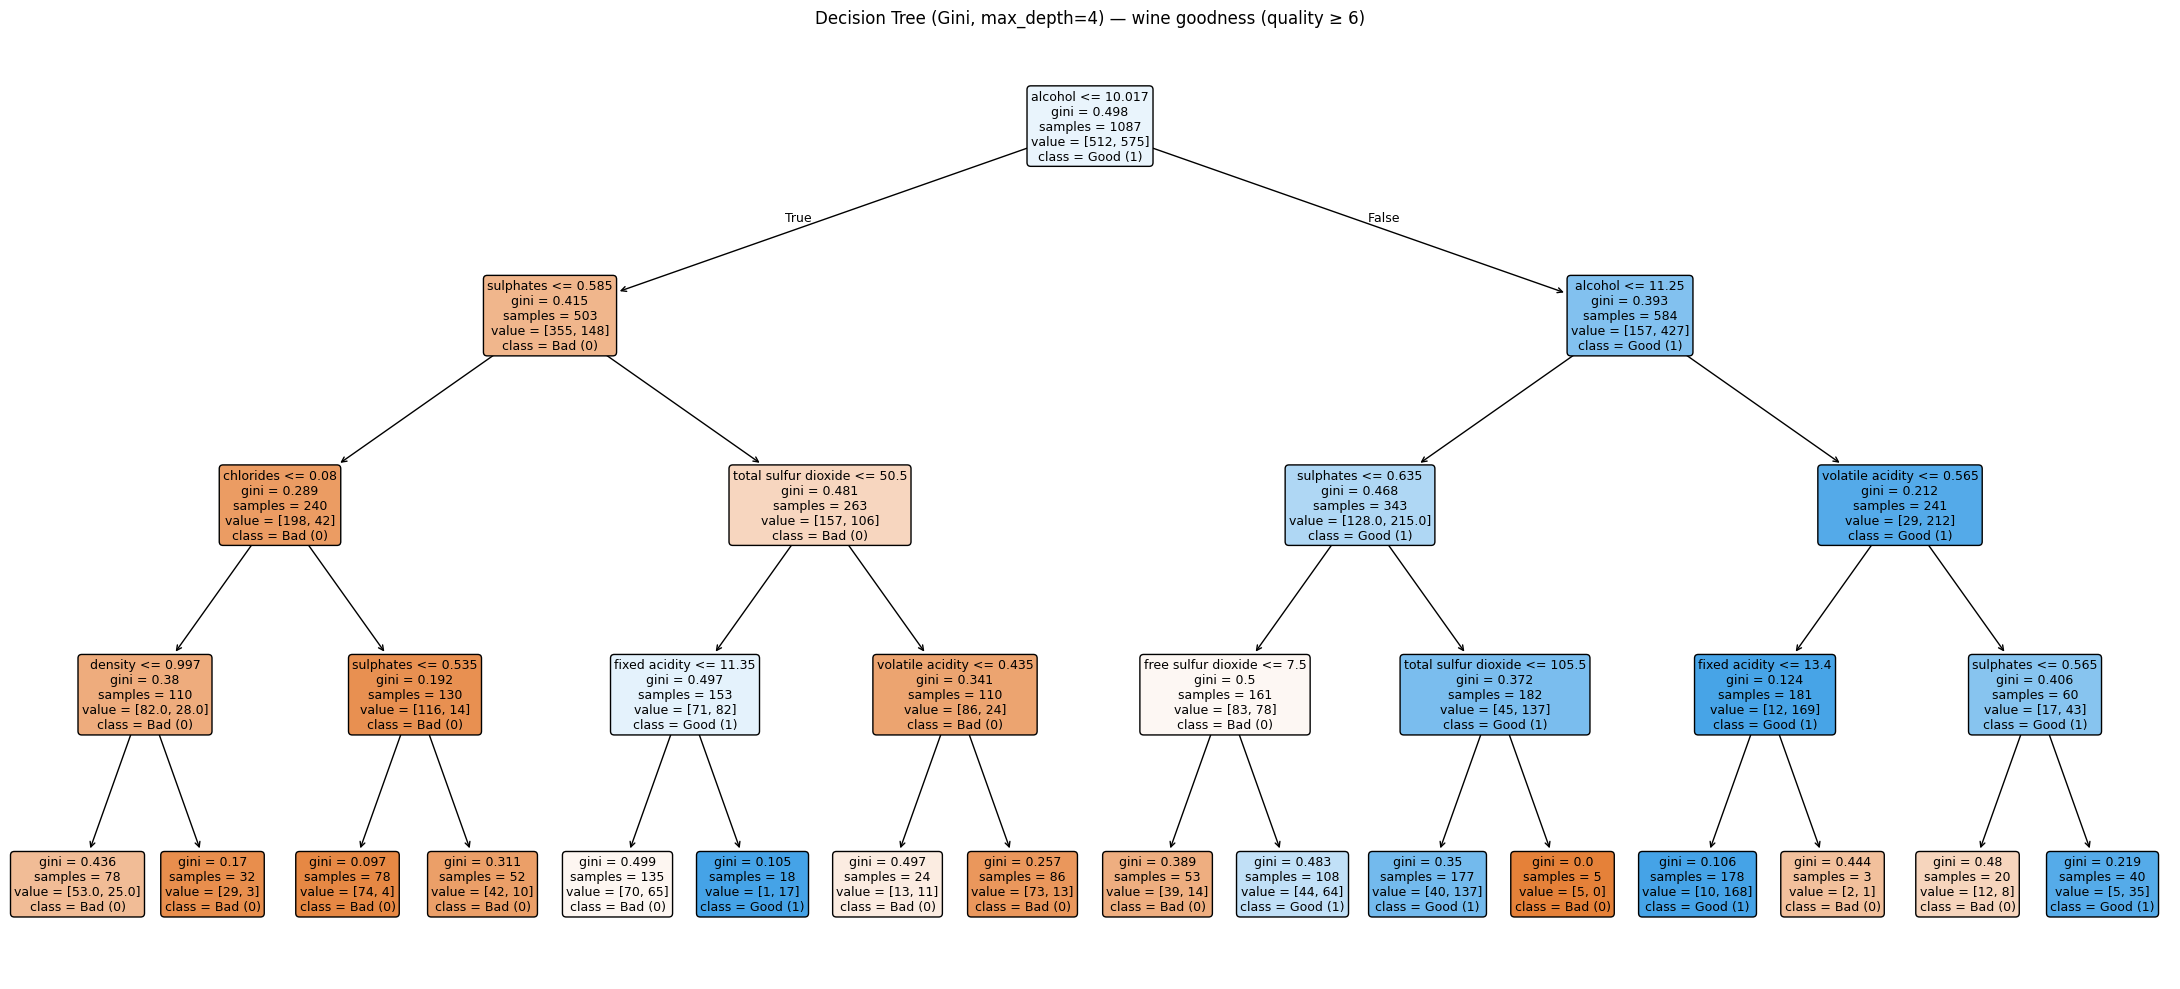

In [11]:
# Decision tree visualization (Question 2 pipeline, already fit on X_train, y_train)
dt_clf = pipe_dt.named_steps["clf"]

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_clf,
    feature_names=feature_names,
    class_names=["Bad (0)", "Good (1)"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision Tree (Gini, max_depth=4) — wine goodness (quality ≥ 6)")
plt.tight_layout()
plt.show()

## Question 6 — Feature importance (Decision Tree vs Random Forest vs XGBoost)

We sort importances and plot the **top features** for each model (all trained on `X_train, y_train`).

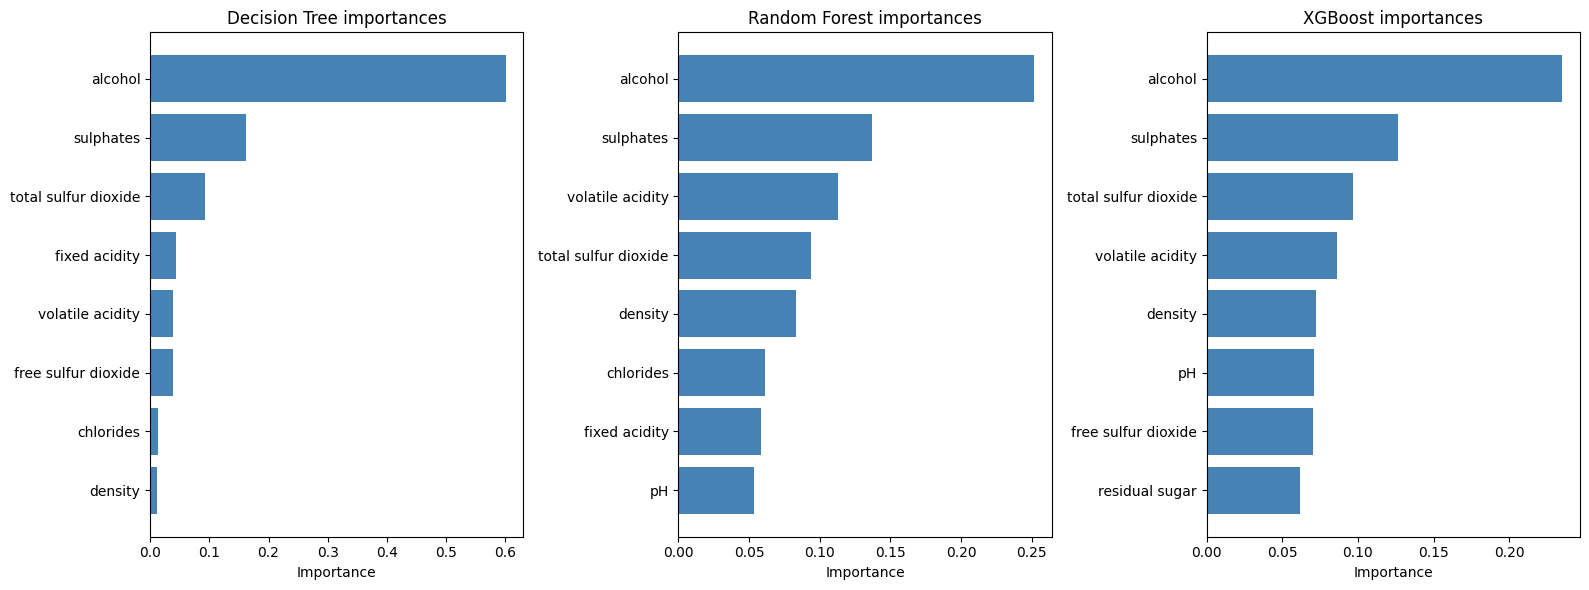

,feature,dt,rf,xgb
10,alcohol,0.600388,0.251577,0.235040
9,sulphates,0.161413,0.136784,0.126281
1,volatile acidity,0.038544,0.113168,0.086420
6,total sulfur dioxide,0.092818,0.093552,0.096773
7,density,0.011552,0.083559,0.071932
4,chlorides,0.012722,0.061537,0.061127
0,fixed acidity,0.044590,0.058310,0.061477
8,pH,0.000000,0.053436,0.070973
2,citric acid,0.000000,0.053012,0.058220
5,free sulfur dioxide,0.037972,0.049564,0.069971


In [12]:
def top_importance_plot(importances, title, ax, top_n=8):
    idx = np.argsort(importances)[::-1][:top_n]
    names = [feature_names[i] for i in idx]
    vals = importances[idx]
    ax.barh(names[::-1], vals[::-1], color="steelblue")
    ax.set_title(title)


imp_dt = pipe_dt.named_steps["clf"].feature_importances_
imp_rf = pipe_rf.named_steps["clf"].feature_importances_
imp_xgb = pipe_xgb.named_steps["clf"].feature_importances_

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharex=False)
top_importance_plot(imp_dt, "Decision Tree importances", axes[0])
top_importance_plot(imp_rf, "Random Forest importances", axes[1])
top_importance_plot(imp_xgb, "XGBoost importances", axes[2])

for ax in axes:
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

comparison = pd.DataFrame(
    {
        "feature": feature_names,
        "dt": imp_dt,
        "rf": imp_rf,
        "xgb": imp_xgb,
    }
).sort_values("rf", ascending=False)

display(comparison.head(12))

### Summary table — held-out test metrics for all models

In [13]:
metrics_df = pd.DataFrame(metrics_rows).set_index("model")
display(metrics_df.round(4))

best_f1 = metrics_df["f1"].idxmax()
print(f"Best test F1 (positive=Good): {best_f1}")

,accuracy,precision,recall,f1
model,,,,
Decision Tree (Gini),0.6875,0.7438,0.6250,0.6792
Gaussian Naive Bayes,0.7316,0.7630,0.7153,0.7384
Random Forest,0.7610,0.7926,0.7431,0.7670
XGBoost,0.7647,0.7985,0.7431,0.7698


Best test F1 (positive=Good): XGBoost
